# **0. 사용할 패키지 불러오기**

In [1]:
import numpy as np
#from keras.utils import np_utils
from keras.utils import to_categorical
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation

# **1. 데이터셋 생성하기**

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255.0
x_test = x_test.reshape(10000, 784).astype('float32') / 255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

11490434/11490434 [==============================] - 1s 0us/step


# **2. 모델 구성하기**

In [3]:
model = Sequential()
model.add(Dense(units=64, input_dim=28*28, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

# **3. 모델 학습과정 설정하기**

In [4]:
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# **4. 모델 학습시키기**

In [5]:
hist = model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.6678 - accuracy: 0.8277
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3433 - accuracy: 0.9044
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2967 - accuracy: 0.9164
Epoch 4/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2681 - accuracy: 0.9243
Epoch 5/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2460 - accuracy: 0.9303
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2278 - accuracy: 0.9360
Epoch 7/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2124 - accuracy: 0.9398
Epoch 8/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1989 - accuracy: 0.9437
Epoch 9/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1874 - accuracy: 0.9469
Epoch 10/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.176

# **5. 모델 평가하기**

In [6]:
loss_and_metrics = model.evaluate(x_test, y_test, batch_size=32)
print('## evaluation loss and metrics ##')
print(loss_and_metrics)

313/313 [==============================] - 1s 2ms/step - loss: 0.1736 - accuracy: 0.9499
## evaluation loss and metrics ##
[0.1735680103302002, 0.9498999714851379]


# **6. 모델 사용하기**

In [7]:
import cv2
import matplotlib.pyplot as plt
import glob

1/1 [==============================] - 0s 27ms/step
## probability ##
[[1.0392822e-03 5.2304385e-04 1.5744988e-03 1.8244851e-02 1.3526682e-04
  9.7454321e-01 3.1502277e-05 2.2945063e-04 3.5760847e-03 1.0281327e-04]]
5
5


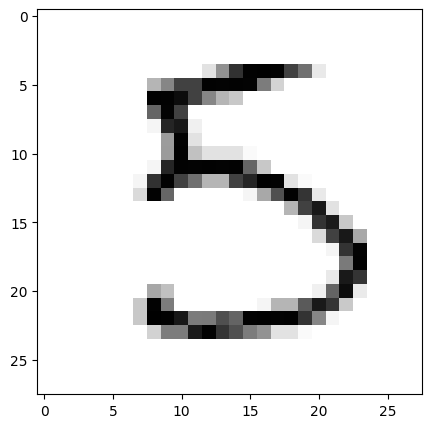

In [12]:
index = 15
xhat = x_test[index:index+1]
yhat = model.predict(xhat)
print('## probability ##')
print(yhat)
print(np.argmax(yhat))
print(np.argmax(y_test[index:index+1]))
plt.figure(figsize=(5, 5))
image = np.reshape(x_test[index], [28, 28])
plt.imshow(image, cmap='Greys')
plt.show()